<a href="https://colab.research.google.com/github/senBenz/ML/blob/main/recommendationSys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ploting clusters with Kmeans function using iris dataset

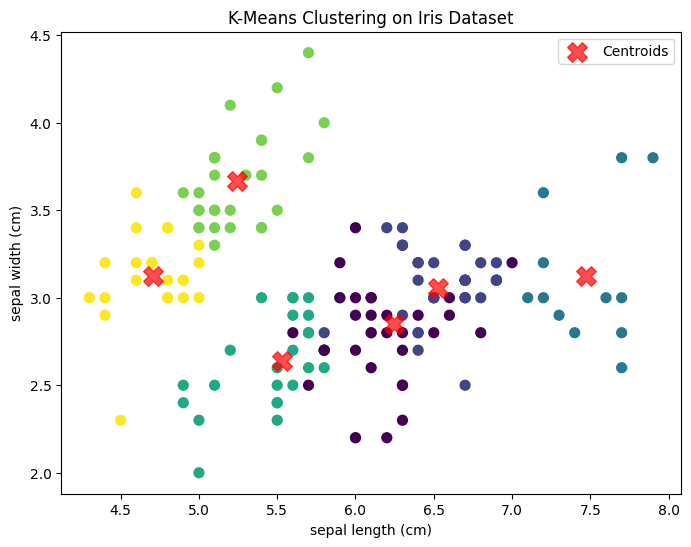

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

data = load_iris()
X = data.data
y = data.target


kmeans = KMeans(
    n_clusters=6,
    init='random',
    n_init='auto',
    max_iter=300,
    tol=1e-4,
    random_state=42
)
kmeans.fit(X)




labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))


plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', s=200, alpha=0.7, marker='X', label='Centroids')

plt.title('K-Means Clustering on Iris Dataset')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.legend()
plt.show()





Testing if the dataset is imported and where we can see the keys of our dataset

In [ ]:
from sklearn.datasets import load_iris

data=load_iris()



print(data.keys())


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


downloading the netflix Prize data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("netflix-inc/netflix-prize-data")

print("Path to dataset files:", path)

AttributeError: 'str' object has no attribute 'keys'

les utilisateurs ayant des goûts similaires (mêmes films regardés ou notés) sont regroupés dans le même cluster,
et le système peut recommander à chaque utilisateur des films aimés par d’autres personnes du même groupe.

Top recommandations (IDs): [26, 3, 18, 5, 7, 11, 17, 12, 21, 25]


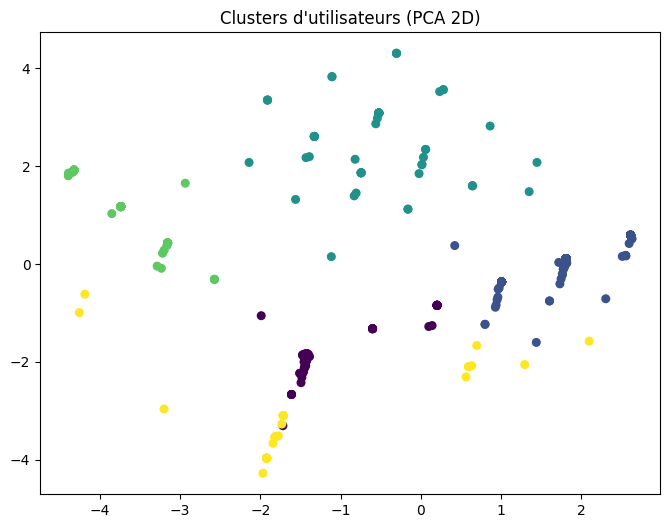

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1) here is where i have loaded the data
path = "/root/.cache/kagglehub/datasets/netflix-inc/netflix-prize-data/versions/2/combined_data_1.txt"
def load_netflix_file(filename, max_lines=None):
    rows = []
    movie_id = None
    with open(filename, 'r') as f:
        for i, line in enumerate(f):
            if max_lines and i >= max_lines: break
            line = line.strip()
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                user_id, rating, _ = line.split(',')
                rows.append((movie_id, int(user_id), int(rating)))
    return pd.DataFrame(rows, columns=["MovieID", "UserID", "Rating"])

df = load_netflix_file(path, max_lines=200000)

# 2) Pivot
user_movie = df.pivot_table(index="UserID", columns="MovieID", values="Rating", fill_value=0)

# 3) i this section we are using the sample
sample = user_movie.sample(n=500, random_state=42)
X = sample.values
Xc = X - X.mean(axis=1, keepdims=True)

# 4) in this section we are using the Kmeans function
k = 5
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans.fit(Xc)
labels = kmeans.labels_
sample['Cluster'] = labels

# 5) Reco pour un utilisateur d'exemple
user_id = sample.index[0]
user_cluster = sample.loc[user_id, 'Cluster']
similar_users = sample[sample['Cluster'] == user_cluster].index.tolist()
high_rated = df[df['UserID'].isin(similar_users) & (df['Rating'] >= 4)]
reco = high_rated.groupby('MovieID')['Rating'].mean().sort_values(ascending=False)
user_seen = set(df[df['UserID'] == user_id]['MovieID'])
recommendations = [mid for mid in reco.index if mid not in user_seen]
print("Top recommandations (IDs):", recommendations[:10])

# 6) Visualiser
pca = PCA(n_components=2)
reduced = pca.fit_transform(Xc)
plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, s=30)
plt.title("Clusters d'utilisateurs (PCA 2D)")
plt.show()

In [ ]:
teste matplotlib

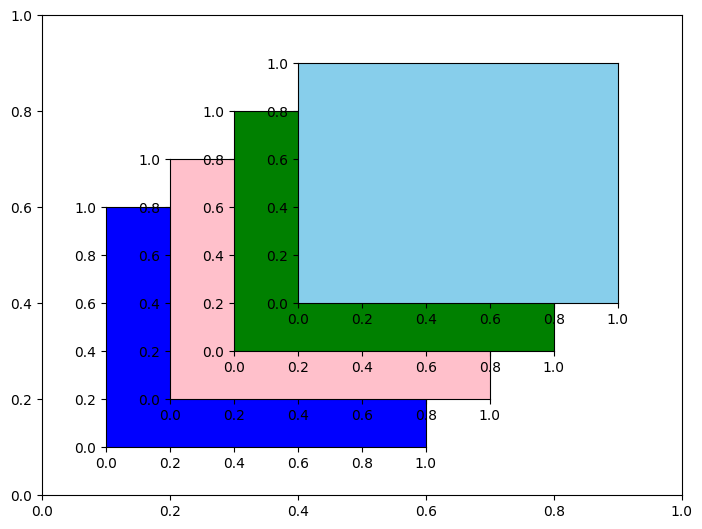

In [ ]:
import matplotlib.pyplot as plt


plt.axes([0.0,0.0,1,1])
plt.axes([0.1,0.1,0.5,0.5],facecolor="blue")
plt.axes([0.2,0.2,0.5,0.5],facecolor="pink")
plt.axes([0.3,0.3,0.5,0.5],facecolor="green")
plt.axes([0.4,0.4,0.5,0.5],facecolor="skyblue")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

Leet code rain water

In [ ]:

#leet code rain water probleemmmmmm



height = [0,1,0,2,1,0,1,3,2,1,2,1]
squares=0
list1=[]
for height[i] in height:
  left=height[i-1]
  right=height[i+1]
  if left < right and left != 0 and right!=0:
      squares = min(left,right)-height[i]
      if squares < 0 :
        squares = 0
      list1.append(squares)
      print(list1)




Dijkstra algorithme

In [ ]:
import tkinter as tk
from tkinter import simpledialog, messagebox

# Fonction Dijkstra + my logic
def dijkstra_algorithm(matrice, depart):
    sommet = len(matrice)
    distances = [float('inf')] * sommet
    distances[depart] = 0
    visited = [False] * sommet
    chemin = [-1] * sommet

    for _ in range(sommet):
        min_distance = float('inf')
        min_index = -1
        for i in range(sommet):
            if not visited[i] and distances[i] < min_distance:
                min_distance = distances[i]
                min_index = i

        if min_index == -1:  # Aucun sommet accessible pour eviter les boucles absorbantes
            break

        visited[min_index] = True
        for j in range(sommet):
            if matrice[min_index][j] != -1 and not visited[j]:
                nouvelle_distance = distances[min_index] + matrice[min_index][j]
                if nouvelle_distance < distances[j]:
                    distances[j] = nouvelle_distance
                    chemin[j] = min_index

    return distances, chemin


class DijkstraApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Algorithme de Dijkstra")

        self.sommets = []
        self.arcs = []
        self.matrice = []
        self.show_welcome_screen()
    def show_welcome_screen(self):
        self.welcome_frame = tk.Frame(self.root)
        self.welcome_frame.pack(fill=tk.BOTH, expand=True)

        welcome_label = tk.Label(
            self.welcome_frame,
            text=(
                "Bonjour et bienvenue dans votre programme Dijkstra !\n\n"
                "Instructions :\n"
                "1. Cliquez sur le canevas pour ajouter des sommets.\n"
                "2. Faites un clic droit pour ajouter des arêtes.\n"
                "3. Appuyez sur 'Commencer Dijkstra' pour calculer le plus court chemin.\n"
                "4. Utilisez 'Réinitialiser' pour recommencer.\n\n"
                "Amusez-vous bien !"
            ),
            font=("Arial", 12),
            justify="center",
            wraplength=500,
        )
        welcome_label.pack(pady=20)

        ok_button = tk.Button(
            self.welcome_frame,
            text="OK",
            font=("Arial", 12, "bold"),
            command=self.show_main_screen,
        )
        ok_button.pack(pady=10)

    def show_main_screen(self):
        self.welcome_frame.destroy()
        self.canvas = tk.Canvas(self.root, width=600, height=400, bg="white")
        self.canvas.pack()
        self.info_label = tk.Label(self.root, text="Cliquez pour ajouter des sommets", font=("Arial", 12))
        self.info_label.pack()
        self.start_button = tk.Button(self.root, text="Commencer Dijkstra", command=self.start_dijkstra)
        self.start_button.pack()
        self.reset_button = tk.Button(self.root, text="Réinitialiser", command=self.reset)
        self.reset_button.pack()
        self.canvas.bind("<Button-1>", self.add_sommet)
        self.canvas.bind("<Button-3>", self.add_arc)
    def add_sommet(self, event):
        x, y = event.x, event.y
        self.sommets.append((x, y))
        sommet_id = len(self.sommets) - 1
        self.canvas.create_oval(x-15, y-15, x+15, y+15, fill="lightblue", outline="black")
        self.canvas.create_text(x, y, text=str(sommet_id), font=("Arial", 10))
        self.update_matrice()

    def add_arc(self, event):
        if len(self.sommets) < 2:
            messagebox.showerror("Erreur", "Ajoutez au moins deux sommets avant d'ajouter des arêtes.")
            return

        sommet1 = self.select_sommet(event.x, event.y)
        if sommet1 is None:
            return

        sommet2 = simpledialog.askinteger("Choix du sommet", f"Saisir le numéro du sommet pour relier à {sommet1}")
        if sommet2 is None or sommet2 >= len(self.sommets) or sommet2 == sommet1:
            messagebox.showerror("Erreur", "Sommet invalide.")
            return

        poids = simpledialog.askinteger("Poids", "Saisir le poids de l'arête")
        if poids is None or poids <= 0:
            messagebox.showerror("Erreur", "Poids invalide.")
            return

        self.arcs.append((sommet1, sommet2, poids))
        self.update_matrice()
        x1, y1 = self.sommets[sommet1]
        x2, y2 = self.sommets[sommet2]
        self.canvas.create_line(x1, y1, x2, y2, arrow=tk.LAST)
        self.canvas.create_text((x1+x2)//2, (y1+y2)//2, text=str(poids), fill="red", font=("Arial", 10))

    def select_sommet(self, x, y):
        for i, (sx, sy) in enumerate(self.sommets):
            if (sx - x)**2 + (sy - y)**2 <= 15**2:
                return i
        return None

    def update_matrice(self):
        n = len(self.sommets)
        self.matrice = [[-1] * n for _ in range(n)]
        for s1, s2, poids in self.arcs:
            self.matrice[s1][s2] = poids

    def start_dijkstra(self):
        if not self.matrice:
            messagebox.showerror("Erreur", "Ajoutez un graphe avant de commencer.")
            return

        depart = simpledialog.askinteger("Point de départ", "Saisir le sommet de départ")
        if depart is None or depart >= len(self.sommets):
            messagebox.showerror("Erreur", "Sommet de départ invalide.")
            return

        distances, chemin = dijkstra_algorithm(self.matrice, depart)
        self.display_results(distances, chemin, depart)

    def display_results(self, distances, chemin, depart):
        result_text = f"Résultats à partir du sommet {depart} :\n"
        for i, d in enumerate(distances):
            result_text += f"Sommet {i}: Distance = {d}, Chemin = {self.get_path(chemin, depart, i)}\n"
        messagebox.showinfo("Résultats", result_text)

    def get_path(self, chemin, depart, end):
        path = []
        while end != -1:
            path.append(end)
            end = chemin[end]
        return " -> ".join(map(str, reversed(path)))

    def reset(self):
        self.canvas.delete("all")
        self.sommets = []
        self.arcs = []
        self.matrice = []

root = tk.Tk()
app = DijkstraApp(root)
root.mainloop()

TclError: no display name and no $DISPLAY environment variable

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)
pd.DataFrame(data)






,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
